# Notebook 03b — Multi-target Models for CLD

## 🎯 Goal

Train machine learning models that predict **late-stage clone performance** using **early-stage features only**.

This mirrors a real CLD workflows where:
- late-outcomes are **not available at selection time**
- decisions must rely on **early measurements + model predictions**

---

## Prediction Targets

We train separate models for three key late-stage outcomes:

### 1. Stability
- `qp_drop_pct`
- Relative drop in qP from early window to late window
- Lower is better

### 2. Productivity
- `late_mean_qp`
- Average late-stage qP
- Higher is better

### 3. Quality (temporary)
- `late_mean_aggregation`
- Lower is better

---

## Modeling Strategy

- Use early-stage features (v2)
- Train **independent Random Forest models** for each target
- Evaluate performance on held-out test data

---

## Important Concept

These models do NOT aim to perfectly predict biology.

Instead, they aim to:

> Rank clones correctly for selection decisions

---

## Downstream Usage (Notebook 04b)

Predicted values from this notebook will be used to:

- Score clones using predicted late performance
- Simulate real CLD selection decisions
- Evaluate selection quality (top 10–20%)

---

## Additional Models (Latent Classes)

We also train classifiers for:

- `is_super` → rare high-value clones
- `is_aggressive` → misleading early performers

## Additional Classifier

We also train a binary classifier for:
- 'stable_label_30pct'
    - 1 = stable (qP drop ≤ 30%)
    - 0 = unstable (qP drop > 30%)

## Why this notebook matters

This notebook is the **prediction engine** of the CLD pipeline.

Its outputs will be used in Notebook 04b to:
- filter unstable or low-quality clones
- rank remaining clones by predicted productivity
- simulate real clone selection decisions

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.stats import spearmanr
from matplotlib import pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error,
    r2_score,
    roc_auc_score,
    average_precision_score,
)

scenario = "legacy"   # "legacy" or "optimized"
n_clones = 5000

DATA_PATH = Path("../data/synthetic/processed") / (
    f"cld_features_with_labels_qp_targets_v2_24_30_{n_clones}_{scenario}.csv"
)

print("Loading:", DATA_PATH)
df = pd.read_csv(DATA_PATH)

rename_map = {
    "qP_mean": "qP_proxy_mean",
    "qP_p10": "qP_proxy_p10",
}
df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

df.head()

Loading: ../data/synthetic/processed/cld_features_with_labels_qp_targets_v2_24_30_5000_legacy.csv


,clone_id,titer_mean,titer_std,titer_min,titer_max,titer_cv,titer_p10,vcd_mean,vcd_std,vcd_min,...,qP_proxy_slope,qP_proxy_slope_3_6,qP_proxy_slope_7_10,qP_proxy_curvature,ddpcr_cn,early_mean_qp,late_mean_qp,late_mean_aggregation,qp_drop_pct,stable_label_30pct
0,CLONE_0001,3.329594,0.231718,3.038644,3.677143,0.069593,3.211430,1.116369e+07,632529.287976,1.011644e+07,...,-6.065050e-09,-9.804111e-09,1.658604e-08,2.639015e-08,4.0,2.991799e-07,1.437208e-07,8.173122,0.519616,0
1,CLONE_0002,0.809159,0.121544,0.646515,1.029448,0.150210,0.857412,1.466332e+07,961363.275997,1.314522e+07,...,1.090439e-09,8.269449e-10,3.961753e-09,3.134808e-09,2.0,5.554610e-08,3.568823e-08,7.854971,0.357496,0
2,CLONE_0003,5.020162,0.427049,4.426309,5.619000,0.085067,4.512218,9.035878e+06,796851.792897,7.517549e+06,...,-2.093974e-08,-4.226795e-08,8.275974e-09,5.054393e-08,5.0,5.600003e-07,2.147891e-07,1.142243,0.616447,0
3,CLONE_0004,1.470888,0.334937,0.949309,1.848296,0.227710,1.124509,1.836343e+07,962793.790256,1.694861e+07,...,-6.983557e-09,-6.841016e-09,-9.167305e-09,-2.326289e-09,4.0,8.092406e-08,1.895158e-08,2.126247,0.765801,0
4,CLONE_0005,3.271652,0.203343,3.045858,3.585816,0.062153,3.045858,1.105298e+07,805278.305154,1.005466e+07,...,-1.144508e-08,-1.218754e-08,-1.332141e-08,-1.133876e-09,6.0,2.977628e-07,1.568152e-07,4.649927,0.473354,0


In [2]:
# --------------------------------------------------
# Prepare X and targets
# --------------------------------------------------
regression_targets = ["qp_drop_pct", "late_mean_qp", "late_mean_aggregation"]
classification_target = "stable_label_30pct"

# keep row order fixed for alignment
df = df.sort_values("clone_id").reset_index(drop=True)
clone_ids = df["clone_id"].copy()

# defensive removal of legacy / leakage-prone columns
legacy_leak_cols = [
    "productivity_drop_pct",   # old (v1) stability target
    "late_mean_titer",         # old (v1) productivity target
    "late_mean_vcd",           # old (v1) late-stage summary
]

# exclude clone_id + current target columns + legacy leak columns from features
drop_cols = ["clone_id"] + regression_targets + [classification_target] + legacy_leak_cols
X = df.drop(columns=drop_cols, errors="ignore").copy()

# numeric imputation only
X = X.fillna(X.median(numeric_only=True))

# regression targets
y_drop = df["qp_drop_pct"].copy().clip(lower=0.0, upper=1.0)
y_prod = df["late_mean_qp"].copy()
y_agg = df["late_mean_aggregation"].copy().clip(lower=0.0, upper=100.0)

# classification target
y_stable = df[classification_target].copy().astype(int)

print("Dropped from X:", [c for c in drop_cols if c in df.columns])
print("X shape:", X.shape)
print("Regression targets:", y_drop.shape, y_prod.shape, y_agg.shape)
print("Stable classifier target:", y_stable.shape)

Dropped from X: ['clone_id', 'qp_drop_pct', 'late_mean_qp', 'late_mean_aggregation', 'stable_label_30pct']
X shape: (5000, 52)
Regression targets: (5000,) (5000,) (5000,)
Stable classifier target: (5000,)


In [3]:
# --------------------------------------------------
# Train / test split
# --------------------------------------------------
idx = np.arange(len(df))
train_idx, test_idx = train_test_split(
    idx, test_size=0.2, random_state=42, shuffle=True
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

id_train = clone_ids.iloc[train_idx].values
id_test = clone_ids.iloc[test_idx].values

# regression
y_drop_train = y_drop.iloc[train_idx].values
y_drop_test = y_drop.iloc[test_idx].values

y_prod_train = y_prod.iloc[train_idx].values
y_prod_test = y_prod.iloc[test_idx].values

y_agg_train = y_agg.iloc[train_idx].values
y_agg_test = y_agg.iloc[test_idx].values

# classification
y_stable_train = y_stable.iloc[train_idx].values
y_stable_test = y_stable.iloc[test_idx].values

print("Train size:", len(train_idx), "Test size:", len(test_idx))
print("Stable prevalence (train/test):", y_stable_train.mean(), y_stable_test.mean())

Train size: 4000 Test size: 1000
Stable prevalence (train/test): 0.1675 0.168


In [4]:
# --------------------------------------------------
# Train 3 Random Forest regressors
# --------------------------------------------------
def fit_rf(X_train, y_train):
    model = RandomForestRegressor(
        n_estimators=600,
        random_state=42,
        min_samples_leaf=5,
        max_features="sqrt",
    )
    model.fit(X_train, y_train)
    return model

rf_drop = fit_rf(X_train, y_drop_train)
rf_prod = fit_rf(X_train, y_prod_train)
rf_agg = fit_rf(X_train, y_agg_train)

def eval_model(name, model, X_test, y_test):
    pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    print(f"{name:22s} MAE={mae:.4f}  R2={r2:.4f}")
    return pred

pred_drop = eval_model("qp_drop (stability)", rf_drop, X_test, y_drop_test)
pred_prod = eval_model("late_qp (productivity)", rf_prod, X_test, y_prod_test)
pred_agg = eval_model("late_agg (quality)", rf_agg, X_test, y_agg_test)

qp_drop (stability)    MAE=0.0872  R2=0.5133
late_qp (productivity) MAE=0.0000  R2=0.0215
late_agg (quality)     MAE=1.9109  R2=0.4648


In [5]:
# --------------------------------------------------
# Stable / unstable classifier
# --------------------------------------------------
def fit_rf_clf(X_train, y_train):
    clf = RandomForestClassifier(
        n_estimators=600,
        random_state=42,
        min_samples_leaf=5,
        max_features="sqrt",
        class_weight="balanced_subsample",
    )
    clf.fit(X_train, y_train)
    return clf

rf_stable = fit_rf_clf(X_train, y_stable_train)

pred_stable_prob = rf_stable.predict_proba(X_test)[:, 1]
pred_stable_label = (pred_stable_prob >= 0.5).astype(int)

print("=== Stable classifier ===")
print("ROC-AUC:", roc_auc_score(y_stable_test, pred_stable_prob))
print("Average Precision:", average_precision_score(y_stable_test, pred_stable_prob))
print("Predicted stable rate:", pred_stable_label.mean())

=== Stable classifier ===
ROC-AUC: 0.7809065934065934
Average Precision: 0.40575943111495455
Predicted stable rate: 0.082


## Auxiliary classifiers: super clone / aggressive clone

We train two additional classifiers using the same early features:

- `is_super`: rare commercial winner (high P + high S + sustained late performance)
- `is_aggressive`: attractive early false positive (good early productivity, weak stability later)

Why do this?
- The regression models predict late continuous targets
- But the subgroup labels capture biologically meaningful latent regimes
- These classifiers can later be combined into a decision rule:
  - prefer high super probability
  - avoid high aggressive probability

In [6]:
# --------------------------------------------------
# Auxiliary classifiers: super / aggressive
# - Works for both legacy and optimized
# - Automatically skips if a subgroup has only one class in train set
# --------------------------------------------------

LATENT_PATH = Path(f"../data/synthetic/raw/clone_latent_truths_5000_{scenario}.csv")
lat_labels = pd.read_csv(LATENT_PATH)[["clone_id", "is_super", "is_aggressive"]]

# Align labels to the same clone order as df / X
label_df = df[["clone_id"]].merge(lat_labels, on="clone_id", how="left")
label_df[["is_super", "is_aggressive"]] = (
    label_df[["is_super", "is_aggressive"]].fillna(0).astype(int)
)

y_super = label_df["is_super"].copy()
y_aggr = label_df["is_aggressive"].copy()

# Use the SAME split indices as regression
y_super_train = y_super.iloc[train_idx].values
y_super_test  = y_super.iloc[test_idx].values
y_aggr_train  = y_aggr.iloc[train_idx].values
y_aggr_test   = y_aggr.iloc[test_idx].values

print("Super prevalence (train/test):", float(y_super_train.mean()), float(y_super_test.mean()))
print("Aggressive prevalence (train/test):", float(y_aggr_train.mean()), float(y_aggr_test.mean()))

def fit_rf_clf(X_train, y_train):
    clf = RandomForestClassifier(
        n_estimators=600,
        random_state=42,
        min_samples_leaf=5,
        max_features="sqrt",
        class_weight="balanced_subsample",
    )
    clf.fit(X_train, y_train)
    return clf

def safe_fit_predict_proba(X_train, y_train, X_test, label_name="label"):
    """
    Fit classifier only if training set has both classes.
    Otherwise return zeros so downstream cells still run safely.
    """
    unique_train = np.unique(y_train)

    if len(unique_train) < 2:
        print(f"[SKIP] {label_name}: only one class in training set -> {unique_train.tolist()}")
        return None, np.zeros(len(X_test), dtype=float)

    clf = fit_rf_clf(X_train, y_train)
    proba = clf.predict_proba(X_test)

    # extract positive-class probability safely
    if proba.shape[1] > 1:
        pred_prob = proba[:, 1]
    else:
        pred_prob = np.zeros(len(X_test), dtype=float)

    return clf, pred_prob

def eval_binary_clf(name, y_true, y_prob, k_list=[5, 10, 20, 50]):
    print(f"\n=== {name} ===")
    print("Prevalence:", float(np.mean(y_true)))

    # ROC-AUC / AP only meaningful if both classes exist in test
    if len(np.unique(y_true)) == 2:
        print("ROC-AUC:", float(roc_auc_score(y_true, y_prob)))
        print("Average Precision:", float(average_precision_score(y_true, y_prob)))
    else:
        print("ROC-AUC: n/a (single class in test)")
        print("Average Precision: n/a (single class in test)")

    rows = []
    order = np.argsort(-y_prob)
    for k in k_list:
        top_idx = order[:k]
        capture = float(np.mean(y_true[top_idx]))
        rows.append({"k": k, "capture_rate": capture})

    out = pd.DataFrame(rows)
    display(out)
    return out

# Default outputs so downstream cells never break
rf_super = None
rf_aggr = None
pred_super_prob = np.zeros(len(X_test), dtype=float)
pred_aggr_prob = np.zeros(len(X_test), dtype=float)
super_capture = None
aggr_capture = None

# Super classifier
rf_super, pred_super_prob = safe_fit_predict_proba(
    X_train, y_super_train, X_test, label_name="is_super"
)

# Aggressive classifier
rf_aggr, pred_aggr_prob = safe_fit_predict_proba(
    X_train, y_aggr_train, X_test, label_name="is_aggressive"
)

# Evaluate only if classifier actually trained
if rf_super is not None:
    super_capture = eval_binary_clf("Super classifier", y_super_test, pred_super_prob)
else:
    print("\n[INFO] Super classifier skipped.")

if rf_aggr is not None:
    aggr_capture = eval_binary_clf("Aggressive classifier", y_aggr_test, pred_aggr_prob)
else:
    print("\n[INFO] Aggressive classifier skipped.")

Super prevalence (train/test): 0.01625 0.014
Aggressive prevalence (train/test): 0.03725 0.039

=== Super classifier ===
Prevalence: 0.014
ROC-AUC: 0.9791364821790786
Average Precision: 0.5916587504567044


,k,capture_rate
0,5,0.80
1,10,0.60
2,20,0.45
3,50,0.24



=== Aggressive classifier ===
Prevalence: 0.039
ROC-AUC: 0.9999466367832653
Average Precision: 0.9987492182614135


,k,capture_rate
0,5,1.00
1,10,1.00
2,20,1.00
3,50,0.78


In [7]:
if rf_aggr is not None:
    imp_aggr = pd.Series(rf_aggr.feature_importances_, index=X.columns).sort_values(ascending=False)
    print("\n=== Feature importance: aggressive classifier (top 20) ===")
    print(imp_aggr.head(20).to_string())
else:
    print("Aggressive classifier not trained.")


=== Feature importance: aggressive classifier (top 20) ===
titer_slope         0.130110
titer_std           0.128388
viability_mean      0.094503
titer_slope_7_10    0.086519
titer_cv            0.083983
qP_proxy_cv         0.074439
viability_max       0.044436
viability_min       0.034930
vcd_slope           0.033784
viability_p10       0.032187
titer_curvature     0.028865
vcd_p10             0.026131
vcd_mean            0.026097
vcd_max             0.024389
vcd_min             0.022963
aggregation_std     0.022900
titer_slope_3_6     0.018783
titer_max           0.018237
titer_mean          0.016677
titer_min           0.008480


### Evaluate the subgroup classifiers

We use:
- ROC-AUC: ranking quality of probabilities
- Average Precision (AP): more informative under class imbalance
- Top-K capture rate: among the clones with highest predicted subgroup probability,
  how many are truly from that subgroup?

## Rescue scoring for process-optimization candidates

This section adds a first-pass **rescue scoring model**.

A rescue clone is not a direct final selection.  
Instead, it is a clone that has enough upside to justify additional process optimization.

In this notebook, rescue potential is estimated using predicted late-stage outcomes:

- high predicted late qP
- borderline qP drop risk
- borderline aggregation risk
- low-to-moderate aggressive probability
- not already an obvious stable pass clone

The resulting columns are saved into the prediction table for Notebook 04b:

- `pred_rescue_score`
- `pred_rescue_label`

Notebook 04b will later use these values inside the decision engine.

In [8]:
# --------------------------------------------------
# Save prediction table for Notebook 04b
# --------------------------------------------------
OUT_PRED = Path("../data/synthetic/processed") / (
    f"predictions_03b_qp_{n_clones}_{scenario}.csv"
)

pred_table = pd.DataFrame({
    "clone_id": id_test,
    "pred_qp_drop": pred_drop,
    "pred_late_qp": pred_prod,
    "pred_late_agg": pred_agg,
    "pred_stable_prob": pred_stable_prob,
    "pred_stable_label": pred_stable_label,
    "true_qp_drop": y_drop_test,
    "true_late_qp": y_prod_test,
    "true_late_agg": y_agg_test,
    "true_stable_label": y_stable_test,
})

# Optional subgroup classifier outputs
pred_table["pred_super_prob"] = pred_super_prob if "pred_super_prob" in globals() else 0.0
pred_table["pred_aggr_prob"] = pred_aggr_prob if "pred_aggr_prob" in globals() else 0.0

# --------------------------------------------------
# Rescue scoring model — auto-tuned
# --------------------------------------------------
def z01(s):
    s = pd.Series(s).astype(float)
    denom = s.max() - s.min()
    if denom < 1e-12:
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - s.min()) / (denom + 1e-12)

def triangular_band_score(x, low, high, peak=None):
    x = pd.Series(x).astype(float)
    if peak is None:
        peak = (low + high) / 2

    score = pd.Series(np.zeros(len(x)), index=x.index)

    left = (x >= low) & (x <= peak)
    right = (x > peak) & (x <= high)

    score.loc[left] = (x.loc[left] - low) / (peak - low + 1e-12)
    score.loc[right] = (high - x.loc[right]) / (high - peak + 1e-12)

    return score.clip(0, 1)

# Base rescue components
pred_table["rescue_upside_qp"] = z01(pred_table["pred_late_qp"])

pred_table["rescue_stability_band"] = triangular_band_score(
    pred_table["pred_qp_drop"],
    low=0.20,
    high=0.65,
    peak=0.35,
)

pred_table["rescue_quality_band"] = triangular_band_score(
    pred_table["pred_late_agg"],
    low=5.0,
    high=14.0,
    peak=8.5,
)

pred_table["rescue_aggressive_penalty"] = 1.0 - z01(pred_table["pred_aggr_prob"])
pred_table["rescue_not_already_pass"] = 1.0 - z01(pred_table["pred_stable_prob"])

# --------------------------------------------------
# Auto-tune rescue score weights
# --------------------------------------------------
candidate_weights = [
    dict(w_qp=0.20, w_stab=0.35, w_qual=0.30, w_aggr=0.10, w_notpass=0.05),
    dict(w_qp=0.25, w_stab=0.30, w_qual=0.30, w_aggr=0.10, w_notpass=0.05),
    dict(w_qp=0.25, w_stab=0.35, w_qual=0.25, w_aggr=0.10, w_notpass=0.05),
    dict(w_qp=0.30, w_stab=0.30, w_qual=0.25, w_aggr=0.10, w_notpass=0.05),
    dict(w_qp=0.25, w_stab=0.30, w_qual=0.25, w_aggr=0.15, w_notpass=0.05),
    dict(w_qp=0.20, w_stab=0.30, w_qual=0.35, w_aggr=0.10, w_notpass=0.05),
]

RESCUE_FRAC = 0.10

def compute_rescue_score(df, w):
    raw = (
        w["w_qp"] * df["rescue_upside_qp"]
        + w["w_stab"] * df["rescue_stability_band"]
        + w["w_qual"] * df["rescue_quality_band"]
        + w["w_aggr"] * df["rescue_aggressive_penalty"]
        + w["w_notpass"] * df["rescue_not_already_pass"]
    )
    return z01(raw)

def evaluate_rescue_weights(df, w, rescue_frac=0.10):
    tmp = df.copy()
    tmp["score"] = compute_rescue_score(tmp, w)
    thr = tmp["score"].quantile(1 - rescue_frac)
    tmp["label"] = (tmp["score"] >= thr).astype(int)

    rescue = tmp[tmp["label"] == 1]
    non_rescue = tmp[tmp["label"] == 0]

    rescue_qp_ratio = rescue["pred_late_qp"].mean() / (
        non_rescue["pred_late_qp"].mean() + 1e-12
    )
    rescue_stable_rate = rescue["true_stable_label"].mean()
    rescue_agg = rescue["pred_late_agg"].mean()

    stable_target = 0.20
    agg_target = 8.0

    objective = (
        1.00 * np.log1p(rescue_qp_ratio)
        - 1.50 * abs(rescue_stable_rate - stable_target)
        - 0.08 * abs(rescue_agg - agg_target)
    )

    return {
        **w,
        "objective": float(objective),
        "rescue_qp_ratio": float(rescue_qp_ratio),
        "rescue_stable_rate": float(rescue_stable_rate),
        "rescue_pred_late_agg_mean": float(rescue_agg),
        "rescue_threshold": float(thr),
    }

rescue_tuning = pd.DataFrame([
    evaluate_rescue_weights(pred_table, w, rescue_frac=RESCUE_FRAC)
    for w in candidate_weights
]).sort_values("objective", ascending=False)

display(rescue_tuning)

best_w = rescue_tuning.iloc[0].to_dict()

print("=== Best rescue weights ===")
print(best_w)

pred_table["pred_rescue_score"] = compute_rescue_score(pred_table, best_w)

rescue_thr = pred_table["pred_rescue_score"].quantile(1 - RESCUE_FRAC)
pred_table["pred_rescue_label"] = (
    pred_table["pred_rescue_score"] >= rescue_thr
).astype(int)

print("\n=== Rescue scoring summary ===")
print("Rescue threshold:", rescue_thr)
print("Predicted rescue rate:", pred_table["pred_rescue_label"].mean())

print("\n=== Rescue sanity checks ===")
print("Stable rate by rescue label:")
print(pred_table.groupby("pred_rescue_label")["true_stable_label"].mean())

print("\nPredicted late qP by rescue label:")
print(pred_table.groupby("pred_rescue_label")["pred_late_qp"].mean())

print("\nPredicted late aggregation by rescue label:")
print(pred_table.groupby("pred_rescue_label")["pred_late_agg"].mean())

display(
    pred_table.sort_values("pred_rescue_score", ascending=False)[[
        "clone_id",
        "pred_rescue_score",
        "pred_rescue_label",
        "pred_late_qp",
        "pred_qp_drop",
        "pred_late_agg",
        "pred_stable_prob",
        "pred_aggr_prob",
        "true_late_qp",
        "true_qp_drop",
        "true_late_agg",
        "true_stable_label",
    ]].head(15)
)

# --------------------------------------------------
# Save prediction table and create evaluation dataframe
# --------------------------------------------------
pred_table.to_csv(OUT_PRED, index=False)
print("Saved:", OUT_PRED)

# Working evaluation table used by downstream evaluation cells
df_eval = pred_table.copy()

display(df_eval.head())

print("\nColumns in pred_table:")
print(df_eval.columns.tolist())

,w_qp,w_stab,w_qual,w_aggr,w_notpass,objective,rescue_qp_ratio,rescue_stable_rate,rescue_pred_late_agg_mean,rescue_threshold
3,0.30,0.30,0.25,0.10,0.05,1.224570,2.681129,0.22,8.608122,0.634379
4,0.25,0.30,0.25,0.15,0.05,1.144417,2.382041,0.22,8.550781,0.690612
1,0.25,0.30,0.30,0.10,0.05,1.139627,2.371063,0.22,8.570019,0.679264
2,0.25,0.35,0.25,0.10,0.05,0.909992,1.757639,0.24,8.554781,0.689285
5,0.20,0.30,0.35,0.10,0.05,0.897978,1.682013,0.23,8.544873,0.728182
0,0.20,0.35,0.30,0.10,0.05,0.799287,1.421503,0.23,8.501270,0.732831


=== Best rescue weights ===
{'w_qp': 0.3, 'w_stab': 0.3, 'w_qual': 0.25, 'w_aggr': 0.1, 'w_notpass': 0.05, 'objective': 1.2245696033123383, 'rescue_qp_ratio': 2.681128600668039, 'rescue_stable_rate': 0.22, 'rescue_pred_late_agg_mean': 8.60812233518027, 'rescue_threshold': 0.6343786893875846}

=== Rescue scoring summary ===
Rescue threshold: 0.6343786893875846
Predicted rescue rate: 0.1

=== Rescue sanity checks ===
Stable rate by rescue label:
pred_rescue_label
0    0.162222
1    0.220000
Name: true_stable_label, dtype: float64

Predicted late qP by rescue label:
pred_rescue_label
0    1.350846e-07
1    3.621819e-07
Name: pred_late_qp, dtype: float64

Predicted late aggregation by rescue label:
pred_rescue_label
0    5.957043
1    8.608122
Name: pred_late_agg, dtype: float64


,clone_id,pred_rescue_score,pred_rescue_label,pred_late_qp,pred_qp_drop,pred_late_agg,pred_stable_prob,pred_aggr_prob,true_late_qp,true_qp_drop,true_late_agg,true_stable_label
180,CLONE_4625,1.000000,1,4.500575e-06,0.322967,8.670837,0.560659,0.015903,1.238325e-05,0.084353,10.114743,1
621,CLONE_3254,0.787107,1,4.328425e-06,0.246238,8.356089,0.821561,0.007259,7.103148e-06,0.089331,11.556387,1
182,CLONE_1942,0.733136,1,8.271182e-08,0.353795,8.453091,0.379410,0.000000,1.027260e-07,0.239874,8.372210,1
730,CLONE_4878,0.731989,1,3.511339e-06,0.545547,9.662363,0.172336,0.021993,4.912223e-06,0.417981,7.149145,0
825,CLONE_1490,0.725636,1,7.682929e-08,0.351665,8.633797,0.466169,0.001465,6.014583e-08,0.498543,9.131216,0
898,CLONE_3393,0.722734,1,6.424109e-07,0.391027,8.864235,0.295613,0.011043,8.308232e-07,0.314570,3.423687,0
690,CLONE_4335,0.717382,1,3.366004e-07,0.345661,8.935721,0.527962,0.001358,3.337148e-07,0.372991,10.260128,0
269,CLONE_0150,0.714357,1,8.947176e-08,0.353381,8.895115,0.418119,0.000000,7.449001e-08,0.492550,10.871919,0
183,CLONE_0101,0.712995,1,1.215641e-06,0.410018,7.749125,0.156556,0.002909,1.143915e-06,0.514718,5.009296,0
397,CLONE_1651,0.712970,1,1.180543e-07,0.361997,8.297202,0.384705,0.000000,1.341365e-07,0.327738,13.731309,0


Saved: ../data/synthetic/processed/predictions_03b_qp_5000_legacy.csv


,clone_id,pred_qp_drop,pred_late_qp,pred_late_agg,pred_stable_prob,pred_stable_label,true_qp_drop,true_late_qp,true_late_agg,true_stable_label,pred_super_prob,pred_aggr_prob,rescue_upside_qp,rescue_stability_band,rescue_quality_band,rescue_aggressive_penalty,rescue_not_already_pass,pred_rescue_score,pred_rescue_label
0,CLONE_1502,0.498165,2.673129e-08,8.435996,0.238692,0,0.206868,3.215605e-08,4.404966,1,0.001494,0.003219,0.000312,0.506117,0.981713,0.996769,0.710487,0.568590,0
1,CLONE_2587,0.373417,8.407121e-08,3.130765,0.464397,0,0.600740,5.393417e-08,3.662670,0,0.007656,0.000000,0.013124,0.921942,0.000000,1.000000,0.435364,0.416664,0
2,CLONE_2654,0.461606,2.770586e-08,7.582349,0.256485,0,0.156409,3.459109e-08,10.144181,1,0.001523,0.004162,0.000529,0.627981,0.737814,0.995823,0.688798,0.538817,0
3,CLONE_1056,0.348761,7.746555e-08,6.885601,0.507813,1,0.465880,6.392818e-08,2.383546,0,0.012355,0.000000,0.011648,0.991742,0.538743,1.000000,0.382442,0.594558,0
4,CLONE_0706,0.644735,1.744327e-07,8.275030,0.018172,0,0.678633,1.526521e-07,5.032915,0,0.004539,0.039329,0.033316,0.017551,0.935723,0.960529,0.979289,0.407241,0



Columns in pred_table:
['clone_id', 'pred_qp_drop', 'pred_late_qp', 'pred_late_agg', 'pred_stable_prob', 'pred_stable_label', 'true_qp_drop', 'true_late_qp', 'true_late_agg', 'true_stable_label', 'pred_super_prob', 'pred_aggr_prob', 'rescue_upside_qp', 'rescue_stability_band', 'rescue_quality_band', 'rescue_aggressive_penalty', 'rescue_not_already_pass', 'pred_rescue_score', 'pred_rescue_label']


## Utility-based ranking evaluation

This section evaluates whether the model is useful for **clone selection**, not only for raw regression accuracy.

We check:

- **Spearman correlation** for ranking consistency
- **Top-k overlap** between predicted and true utility
- **Top-k true-good rate** among selected clones

This is closer to the real CLD objective:
selecting the best clones early, not just minimizing RMSE.

In [9]:
# --------------------------------------------------
# Spearman + Top-K evaluation
# --------------------------------------------------

def z(s):
    s = pd.Series(s).astype(float)
    return (s - s.mean()) / (s.std(ddof=0) + 1e-9)

def spearman(a, b):
    return spearmanr(a, b).correlation

def topk_overlap(true_scores, pred_scores, k):
    true_top = set(pd.Series(true_scores).nlargest(k).index)
    pred_top = set(pd.Series(pred_scores).nlargest(k).index)
    return len(true_top & pred_top) / k

def topk_recall_of_true_good(pred_rank, true_good_mask, k):
    top_idx = pred_rank.nlargest(k).index
    return true_good_mask.loc[top_idx].mean()

required_eval_cols = [
    "true_qp_drop", "pred_qp_drop",
    "true_late_qp", "pred_late_qp",
    "true_late_agg", "pred_late_agg"
]
missing_eval = [c for c in required_eval_cols if c not in df_eval.columns]
if missing_eval:
    raise ValueError(f"df_eval is missing required columns: {missing_eval}")

print("=== Spearman (ranking correlation) ===")
print("qp_drop (lower better):", spearman(-df_eval["true_qp_drop"], -df_eval["pred_qp_drop"]))
print("late_qp (higher better):", spearman(df_eval["true_late_qp"], df_eval["pred_late_qp"]))
print("late_agg (lower better):", spearman(-df_eval["true_late_agg"], -df_eval["pred_late_agg"]))

# biosimilar utility
df_eval["true_util_bio"] = (
    1.0 * z(df_eval["true_late_qp"])
    - 1.0 * z(df_eval["true_qp_drop"])
    - 0.2 * z(df_eval["true_late_agg"])
)
df_eval["pred_util_bio"] = (
    1.0 * z(df_eval["pred_late_qp"])
    - 1.0 * z(df_eval["pred_qp_drop"])
    - 0.2 * z(df_eval["pred_late_agg"])
)

# novel / ADC utility
df_eval["true_util_novel"] = (
    1.0 * z(df_eval["true_late_qp"])
    - 1.0 * z(df_eval["true_qp_drop"])
    - 1.0 * z(df_eval["true_late_agg"])
)
df_eval["pred_util_novel"] = (
    1.0 * z(df_eval["pred_late_qp"])
    - 1.0 * z(df_eval["pred_qp_drop"])
    - 1.0 * z(df_eval["pred_late_agg"])
)

K_LIST = [5, 10, 20, 50]

print("\n=== Top-K evaluation using biosimilar utility ===")
for k in K_LIST:
    overlap = topk_overlap(df_eval["true_util_bio"], df_eval["pred_util_bio"], k)
    print(f"Top-{k} overlap (true vs pred utility): {overlap:.3f}")

GOOD_FRAC = 0.10
good_threshold = df_eval["true_util_bio"].quantile(1 - GOOD_FRAC)
df_eval["true_good_bio"] = df_eval["true_util_bio"] >= good_threshold

print("\n=== Top-K true-good rate among predicted picks (biosimilar) ===")
pred_rank = df_eval["pred_util_bio"]
for k in K_LIST:
    rate = topk_recall_of_true_good(pred_rank, df_eval["true_good_bio"], k)
    print(f"Predicted top-{k}: fraction that are truly top {int(GOOD_FRAC*100)}% good = {rate:.3f}")

=== Spearman (ranking correlation) ===
qp_drop (lower better): 0.6302075897700808
late_qp (higher better): 0.9626636186636187
late_agg (lower better): 0.6749096669096669

=== Top-K evaluation using biosimilar utility ===
Top-5 overlap (true vs pred utility): 0.400
Top-10 overlap (true vs pred utility): 0.300
Top-20 overlap (true vs pred utility): 0.250
Top-50 overlap (true vs pred utility): 0.260

=== Top-K true-good rate among predicted picks (biosimilar) ===
Predicted top-5: fraction that are truly top 10% good = 1.000
Predicted top-10: fraction that are truly top 10% good = 0.500
Predicted top-20: fraction that are truly top 10% good = 0.400
Predicted top-50: fraction that are truly top 10% good = 0.360


In [10]:
# --------------------------------------------------
# Feature importance
# --------------------------------------------------
imp_drop = pd.Series(rf_drop.feature_importances_, index=X.columns).sort_values(ascending=False)
imp_prod = pd.Series(rf_prod.feature_importances_, index=X.columns).sort_values(ascending=False)
imp_agg = pd.Series(rf_agg.feature_importances_, index=X.columns).sort_values(ascending=False)
imp_stable = pd.Series(rf_stable.feature_importances_, index=X.columns).sort_values(ascending=False)

print("\n=== Top features: qp_drop ===")
print(imp_drop.head(15).to_string())

print("\n=== Top features: late_qp ===")
print(imp_prod.head(15).to_string())

print("\n=== Top features: late_agg ===")
print(imp_agg.head(15).to_string())

print("\n=== Top features: stable classifier ===")
print(imp_stable.head(15).to_string())

if rf_aggr is not None:
    imp_aggr = pd.Series(rf_aggr.feature_importances_, index=X.columns).sort_values(ascending=False)
    print("\n=== Top features: aggressive classifier ===")
    print(imp_aggr.head(15).to_string())
else:
    print("\nAggressive classifier not trained.")


=== Top features: qp_drop ===
titer_slope         0.186301
titer_std           0.138479
titer_slope_7_10    0.066268
titer_slope_3_6     0.053586
qP_proxy_cv         0.051082
titer_cv            0.043397
viability_mean      0.034523
vcd_slope           0.032334
viability_min       0.021865
vcd_mean            0.020614
vcd_max             0.019306
titer_max           0.019164
vcd_p10             0.018959
titer_mean          0.018313
titer_p10           0.016507

=== Top features: late_qp ===
titer_p10         0.141082
titer_min         0.133619
qP_proxy_p10      0.073281
qP_proxy_min      0.071589
titer_mean        0.063864
vcd_p10           0.051860
vcd_mean          0.050432
vcd_max           0.045371
viability_mean    0.043573
viability_p10     0.041742
qP_proxy_mean     0.038164
early_mean_qp     0.031332
titer_max         0.030101
titer_cv          0.028468
vcd_min           0.025602

=== Top features: late_agg ===
aggregation_mean          0.152476
aggregation_p10           0.150

## A) Define two utility modes (business objectives)

We evaluate two different "success definitions" depending on business goals.

### 1) Biosimilar / commercial volume mode
- Prioritize **high productivity** (late qP ↑)
- Prioritize **stability** (qP drop ↓)
- Quality (aggregation) matters, but with a **lower weight**

### 2) Novel / ADC / high-quality mode
- Prioritize **quality** (aggregation ↓) more strongly
- Still require productivity and stability, but quality has a higher weight

We compute utility from:

- **true late outcomes** ("offline evaluation")
- **predicted late outcomes** ("model-based ranking")

In [11]:
# --------------------------------------------------
# Utility-based ranking evaluation
# --------------------------------------------------

def z(s: pd.Series) -> pd.Series:
    s = s.astype(float)
    return (s - s.mean()) / (s.std(ddof=0) + 1e-9)

# ---- Required columns in df_eval (test-set prediction table) ----
required = [
    "true_qp_drop",
    "pred_qp_drop",
    "true_late_qp",
    "pred_late_qp",
    "true_late_agg",
    "pred_late_agg",
]
missing = [c for c in required if c not in df_eval.columns]
if missing:
    raise ValueError(
        f"df_eval is missing required columns: {missing}. "
        "Make sure 03b created df_eval with qP-based true/pred targets."
    )

# ---- Utility weights ----
# Biosimilar: productivity + stability dominate
W_BIO = dict(qp=1.0, drop=1.0, agg=0.2)

# Novel/ADC: quality gets larger weight
W_NOVEL = dict(qp=1.0, drop=1.0, agg=1.0)

def compute_utility(df: pd.DataFrame, weights: dict, prefix: str) -> pd.Series:
    return (
        weights["qp"] * z(df[f"{prefix}_late_qp"])
        - weights["drop"] * z(df[f"{prefix}_qp_drop"])
        - weights["agg"] * z(df[f"{prefix}_late_agg"])
    )

# Create z-score utilities (true vs predicted) for both modes
df_eval["true_util_bio"] = compute_utility(df_eval, W_BIO, "true")
df_eval["pred_util_bio"] = compute_utility(df_eval, W_BIO, "pred")

df_eval["true_util_novel"] = compute_utility(df_eval, W_NOVEL, "true")
df_eval["pred_util_novel"] = compute_utility(df_eval, W_NOVEL, "pred")

display(df_eval[[
    "true_util_bio", "pred_util_bio",
    "true_util_novel", "pred_util_novel"
]].head())

,true_util_bio,pred_util_bio,true_util_novel,pred_util_novel
0,1.550478,-0.977650,2.009245,-1.755465
1,-0.804406,0.773624,-0.161434,1.859755
2,1.502466,-0.568919,0.537017,-1.046813
3,0.098570,0.649212,1.058963,0.416115
4,-1.355847,-1.890491,-1.052909,-2.611753


## B) Redefine "bottom-right" using utility (top-X% elite)

The traditional CLD "bottom-right" idea uses two thresholds:

- **late qP / productivity** in the top quantile
- **qP drop** in the bottom quantile

However, our CLD decision is now **multi-objective**:

- productivity
- stability
- quality

So instead of using a simple two-threshold rule, we redefine "bottom-right" as:

> **Elite set = top X% by true utility**

We compute elite sets for:

- Biosimilar utility mode
- Novel / ADC utility mode

This makes evaluation consistent with how clones will later be ranked in the decision engine.

In [12]:
# Elite definitions by utility
GOOD_FRAC_LIST = [0.10, 0.05, 0.02, 0.01]   # top 10%, 5%, 2%, 1%

def mark_elite(df: pd.DataFrame, util_col: str, frac: float, out_col: str):
    thr = df[util_col].quantile(1 - frac)
    df[out_col] = (df[util_col] >= thr).astype(int)
    return thr

elite_thresholds = []

for frac in GOOD_FRAC_LIST:
    pct = int(frac * 100)

    thr_bio = mark_elite(df_eval, "true_util_bio", frac, f"elite_bio_{pct}")
    thr_nov = mark_elite(df_eval, "true_util_novel", frac, f"elite_novel_{pct}")

    elite_thresholds.append({
        "frac": frac,
        "thr_true_util_bio": float(thr_bio),
        "thr_true_util_novel": float(thr_nov),
        "n_elite_bio": int(df_eval[f"elite_bio_{pct}"].sum()),
        "n_elite_novel": int(df_eval[f"elite_novel_{pct}"].sum()),
    })

elite_thresholds_df = pd.DataFrame(elite_thresholds)
elite_thresholds_df

,frac,thr_true_util_bio,thr_true_util_novel,n_elite_bio,n_elite_novel
0,0.10,1.212313,1.824468,100,100
1,0.05,1.504822,2.204324,50,50
2,0.02,1.828556,2.602969,20,20
3,0.01,2.319256,2.945288,10,10


## C) Dominance + Top-K capture comparison (biosimilar vs novel)

We compare how well predicted utilities recover elite clones under two modes:

### Metrics
1) **Spearman**: ranking correlation between true utility and predicted utility
2) **Top-K overlap**: how many of the predicted top-K are also in true top-K (strict)
3) **Top-K elite rate**: among predicted top-K, what fraction are in the true elite set (practical)
4) **Subgroup capture** (if available): super/aggressive fractions among predicted top-K

This mirrors real CLD decision making:
- You keep only a small Top-K set for late-stage validation.

In [13]:
from scipy.stats import spearmanr

K_LIST = [5, 10, 20, 50]

def topk_overlap(true_score: pd.Series, pred_score: pd.Series, k: int) -> float:
    true_top = set(true_score.sort_values(ascending=False).head(k).index)
    pred_top = set(pred_score.sort_values(ascending=False).head(k).index)
    return len(true_top & pred_top) / k

def elite_rate_in_topk(df: pd.DataFrame, pred_util_col: str, elite_col: str, k: int) -> float:
    top = df.sort_values(pred_util_col, ascending=False).head(k)
    return float(top[elite_col].mean())

def subgroup_rates_in_topk(df: pd.DataFrame, pred_util_col: str, k: int):
    top = df.sort_values(pred_util_col, ascending=False).head(k)
    out = {}
    if "true_is_super" in top.columns:
        out["super_rate"] = float(top["true_is_super"].mean())
    if "ture_is_aggressive" in top.columns:
        out["aggressive_rate"] = float(top["true_is_aggressive"].mean())
    return out

def eval_mode(mode_name: str, true_util: str, pred_util: str, elite_col: str):
    print(f"\n==================== {mode_name} ====================")
    # Spearman (ranking)
    rho = spearmanr(df_eval[true_util], df_eval[pred_util]).correlation
    print("Spearman(true_util vs pred_util):", rho)

    rows = []
    for k in K_LIST:
        rows.append({
            "mode": mode_name,
            "k": k,
            "topk_overlap": topk_overlap(df_eval[true_util], df_eval[pred_util], k),
            "elite_rate_in_topk": elite_rate_in_topk(df_eval, pred_util, elite_col, k),
            **subgroup_rates_in_topk(df_eval, pred_util, k),
        })

    out = pd.DataFrame(rows)
    display(out)
    return out

# Evaluate both modes at elite top-10% (you can change to elite_bio_5 / elite_bio_1, etc.)
res_bio = eval_mode(
    "Biosimilar mode (elite = top10%)",
    true_util = "true_util_bio",
    pred_util = "pred_util_bio",
    elite_col = "elite_bio_10",
)

res_novel = eval_mode(
    "Novel/ADC mode (elite = top10%)",
    true_util = "true_util_novel",
    pred_util = "pred_util_novel",
    elite_col = "elite_novel_10",
)

res_bio_2 = eval_mode(
    "Biosimilar mode (elite = top2%)",
    true_util ='true_util_bio',
    pred_util = "pred_util_bio",
    elite_col = "elite_bio_2" 
)

res_novel_2 = eval_mode(
    "Novel/ADC mode (elite = top2%)",
    true_util = "true_util_novel",
    pred_util = "pred_util_novel",
    elite_col = "elite_novel_2"
)


# Combine results for side-by-side viewing
results_compare = pd.concat([res_bio, res_novel, res_bio_2, res_novel_2], 
                            ignore_index=True)
results_compare


==================== Biosimilar mode (elite = top10%) ====================
Spearman(true_util vs pred_util): 0.5867480627480628


,mode,k,topk_overlap,elite_rate_in_topk
0,Biosimilar mode (elite = top10%),5,0.40,1.00
1,Biosimilar mode (elite = top10%),10,0.30,0.50
2,Biosimilar mode (elite = top10%),20,0.25,0.40
3,Biosimilar mode (elite = top10%),50,0.26,0.36



==================== Novel/ADC mode (elite = top10%) ====================
Spearman(true_util vs pred_util): 0.6636510996510997


,mode,k,topk_overlap,elite_rate_in_topk
0,Novel/ADC mode (elite = top10%),5,0.20,0.60
1,Novel/ADC mode (elite = top10%),10,0.10,0.40
2,Novel/ADC mode (elite = top10%),20,0.15,0.40
3,Novel/ADC mode (elite = top10%),50,0.20,0.38



==================== Biosimilar mode (elite = top2%) ====================
Spearman(true_util vs pred_util): 0.5867480627480628


,mode,k,topk_overlap,elite_rate_in_topk
0,Biosimilar mode (elite = top2%),5,0.40,1.00
1,Biosimilar mode (elite = top2%),10,0.30,0.50
2,Biosimilar mode (elite = top2%),20,0.25,0.25
3,Biosimilar mode (elite = top2%),50,0.26,0.14



==================== Novel/ADC mode (elite = top2%) ====================
Spearman(true_util vs pred_util): 0.6636510996510997


,mode,k,topk_overlap,elite_rate_in_topk
0,Novel/ADC mode (elite = top2%),5,0.20,0.20
1,Novel/ADC mode (elite = top2%),10,0.10,0.20
2,Novel/ADC mode (elite = top2%),20,0.15,0.15
3,Novel/ADC mode (elite = top2%),50,0.20,0.10


,mode,k,topk_overlap,elite_rate_in_topk
0,Biosimilar mode (elite = top10%),5,0.40,1.00
1,Biosimilar mode (elite = top10%),10,0.30,0.50
2,Biosimilar mode (elite = top10%),20,0.25,0.40
3,Biosimilar mode (elite = top10%),50,0.26,0.36
4,Novel/ADC mode (elite = top10%),5,0.20,0.60
5,Novel/ADC mode (elite = top10%),10,0.10,0.40
6,Novel/ADC mode (elite = top10%),20,0.15,0.40
7,Novel/ADC mode (elite = top10%),50,0.20,0.38
8,Biosimilar mode (elite = top2%),5,0.40,1.00
9,Biosimilar mode (elite = top2%),10,0.30,0.50


## D) Precision@K and NDCG@K (Top-10% and Top-5% elites)

### Why these metrics?
- We care about **ranking** (Top-K decisions), not perfect numeric prediction.
- R²/MAE can look poor even when Top-K ranking is useful.

### Definitions
**Elite label**:
- elite = top X% by **true utility** (offline evaluation)

**Precision@K**:
- Among the predicted Top-K clones (ranked by predicted utility),
  what fraction are truly elite?

**NDCG@K** (Normalized Discounted Cumulative Gain):
- A ranking-quality score that rewards placing elite clones higher in the list.
- It is more sensitive to the top of the ranking than Spearman.

We compute these for:
- Biosimilar mode utility (pred_util_bio vs elite_bio_*)
- Novel/ADC mode utility (pred_util_novel vs elite_novel_*)
- Elite thresholds: top 10% and top 5%
- K = [5, 10, 20, 50]

In [14]:
K_LIST = [5, 10, 20, 50]

def precision_at_k(df: pd.DataFrame, score_col: str, elite_col: str, k: int) -> float:
    top = df.sort_values(score_col, ascending=False).head(k)
    return float(top[elite_col].mean())

def ndcg_at_k(df: pd.DataFrame, score_col: str, elite_col: str, k: int) -> float:
    """
    NDCG@K with binary relevance (elite=1 else 0).
    """
    top = df.sort_values(score_col, ascending=False).head(k)
    rel = top[elite_col].values.astype(float)

    # DCG: sum(rel_i / log2(i+2))
    discounts = 1.0 / np.log2(np.arange(2, len(rel) + 2))
    dcg = float(np.sum(rel * discounts))

    # IDCG: ideal DCG (sorted rel descending)
    ideal = np.sort(rel)[::-1]
    idcg = float(np.sum(ideal * discounts)) + 1e-12

    return dcg / idcg

def eval_prec_ndcg(df: pd.DataFrame, mode_name: str, score_col: str, elite_col: str):
    rows = []
    for k in K_LIST:
        rows.append({
            "mode": mode_name,
            "elite_def": elite_col,
            "k": k,
            "precision@k": precision_at_k(df, score_col, elite_col, k),
            "ndcg@k": ndcg_at_k(df, score_col, elite_col, k),
        })
    return pd.DataFrame(rows)

# We assume you already created these columns in earlier cells:
# - pred_util_bio, pred_util_novel
# - elite_bio_10, elite_bio_5
# - elite_novel_10, elite_novel_5
needed = ["pred_util_bio","pred_util_novel","elite_bio_10","elite_bio_5","elite_bio_2","elite_novel_10","elite_novel_5", "elite_novel_2"]
missing = [c for c in needed if c not in df_eval.columns]
if missing:
    raise ValueError(f"Missing columns in df_eval: {missing}. "
                     "Make sure you ran the Utility+Elite definition cells first.")

res = []
res.append(eval_prec_ndcg(df_eval, "biosimilar", "pred_util_bio", "elite_bio_10"))
res.append(eval_prec_ndcg(df_eval, "biosimilar", "pred_util_bio", "elite_bio_5"))
res.append(eval_prec_ndcg(df_eval, "biosimilar", "pred_util_bio", "elite_bio_2"))

res.append(eval_prec_ndcg(df_eval, "novel/ADC", "pred_util_novel", "elite_novel_10"))
res.append(eval_prec_ndcg(df_eval, "novel/ADC", "pred_util_novel", "elite_novel_5"))
res.append(eval_prec_ndcg(df_eval, "novel/ADC", "pred_util_novel", "elite_novel_2"))

prec_ndcg_table = pd.concat(res, ignore_index=True)
prec_ndcg_table

,mode,elite_def,k,precision@k,ndcg@k
0,biosimilar,elite_bio_10,5,1.00,1.000000
1,biosimilar,elite_bio_10,10,0.50,1.000000
2,biosimilar,elite_bio_10,20,0.40,0.933654
3,biosimilar,elite_bio_10,50,0.36,0.864667
4,biosimilar,elite_bio_5,5,1.00,1.000000
5,biosimilar,elite_bio_5,10,0.50,1.000000
6,biosimilar,elite_bio_5,20,0.35,0.942419
7,biosimilar,elite_bio_5,50,0.26,0.866578
8,biosimilar,elite_bio_2,5,1.00,1.000000
9,biosimilar,elite_bio_2,10,0.50,1.000000


In [15]:
# Optional: pivot for easier reading
pivot = prec_ndcg_table.pivot_table(
    index=["mode","elite_def","k"],
    values=["precision@k","ndcg@k"]
).reset_index()
pivot

,mode,elite_def,k,ndcg@k,precision@k
0,biosimilar,elite_bio_10,5,1.000000,1.00
1,biosimilar,elite_bio_10,10,1.000000,0.50
2,biosimilar,elite_bio_10,20,0.933654,0.40
3,biosimilar,elite_bio_10,50,0.864667,0.36
4,biosimilar,elite_bio_2,5,1.000000,1.00
5,biosimilar,elite_bio_2,10,1.000000,0.50
6,biosimilar,elite_bio_2,20,1.000000,0.25
7,biosimilar,elite_bio_2,50,0.924108,0.14
8,biosimilar,elite_bio_5,5,1.000000,1.00
9,biosimilar,elite_bio_5,10,1.000000,0.50


## E) Utility Weight Sweep (Grid Search) — Find the best weights for Top-K selection

### Why do this?

Our final CLD decision is multi-objective:

- late productivity (**late qP**): higher is better
- stability loss (**qP drop**): lower is better
- quality risk (**aggregation**): lower is better

But we do NOT know the best trade-off weights in advance.

So we sweep candidate weights and evaluate which combinations produce the best **Top-K clone ranking**.

### What we optimize

We compare predicted ranking quality against true ranking quality using:

- **Precision@K**  
  How many true-elite clones appear in predicted Top-K

- **NDCG@K**  
  Ranking quality, with higher reward for correct ordering near the top

We sweep weights for two business modes:

1. **Biosimilar / commercial mode**  
   prioritize late qP + stability, with lower aggregation weight

2. **Novel / ADC mode**  
   prioritize quality more strongly, with higher aggregation weight

This is an **offline evaluation** step using true late outcomes.

In real CLD deployment, we would apply the selected weights to **predicted late outcomes only**.

In [16]:
# --------------------------------------------------
# E) Utility Weight Sweep (Grid Search)
# --------------------------------------------------

K_LIST = [5, 10, 20, 50]
ELITE_FRACS = [0.10, 0.05, 0.02]   # top 10%, 5%, 2%

def z(s):
    s = s.astype(float)
    return (s - s.mean()) / (s.std(ddof=0) + 1e-9)

def precision_at_k(df, score_col, elite_col, k):
    top = df.sort_values(score_col, ascending=False).head(k)
    return float(top[elite_col].mean())

def ndcg_at_k(df, score_col, elite_col, k):
    top = df.sort_values(score_col, ascending=False).head(k)
    rel = top[elite_col].values.astype(float)
    discounts = 1.0 / np.log2(np.arange(2, len(rel) + 2))
    dcg = float(np.sum(rel * discounts))
    ideal = np.sort(rel)[::-1]
    idcg = float(np.sum(ideal * discounts)) + 1e-12
    return dcg / idcg

def make_utility(df, prefix, w_qp, w_drop, w_agg):
    # utility = + qP - drop - agg (all z-scored)
    return (
        w_qp * z(df[f"{prefix}_late_qp"])
        - w_drop * z(df[f"{prefix}_qp_drop"])
        - w_agg * z(df[f"{prefix}_late_agg"])
    )

def mark_elite(df, util_col, frac):
    thr = df[util_col].quantile(1 - frac)
    return (df[util_col] >= thr).astype(int)

# --- Required columns check ---
required = [
    "true_qp_drop", "pred_qp_drop",
    "true_late_qp", "pred_late_qp",
    "true_late_agg", "pred_late_agg"
]
missing = [c for c in required if c not in df_eval.columns]
if missing:
    raise ValueError(
        f"Missing columns in df_eval: {missing}. "
        "Make sure your prediction table contains qP-based true_* and pred_* columns."
    )

# --- Build a working copy ---
work = df_eval.copy()

# --- Weight grids ---
# Biosimilar: agg weight small
grid_bio = {
    "w_qp": [0.5, 1.0, 1.5, 2.0],
    "w_drop": [0.5, 1.0, 1.5, 2.0],
    "w_agg": [0.0, 0.1, 0.2, 0.3],
}

# Novel/ADC: agg weight larger
grid_novel = {
    "w_qp": [0.5, 1.0, 1.5],
    "w_drop": [0.5, 1.0, 1.5],
    "w_agg": [0.5, 1.0, 1.5, 2.0],
}

def run_sweep(mode_name, grid):
    rows = []

    for w_qp in grid["w_qp"]:
        for w_drop in grid["w_drop"]:
            for w_agg in grid["w_agg"]:
                tmp = work.copy()

                # define utilities
                tmp["true_util"] = make_utility(tmp, "true", w_qp, w_drop, w_agg)
                tmp["pred_util"] = make_utility(tmp, "pred", w_qp, w_drop, w_agg)

                # evaluate for each elite frac and each K
                for frac in ELITE_FRACS:
                    elite_col = f"elite_{int(frac*100)}"
                    tmp[elite_col] = mark_elite(tmp, "true_util", frac)

                    for k in K_LIST:
                        rows.append({
                            "mode": mode_name,
                            "w_qp": w_qp,
                            "w_drop": w_drop,
                            "w_agg": w_agg,
                            "elite_frac": frac,
                            "k": k,
                            "precision@k": precision_at_k(tmp, "pred_util", elite_col, k),
                            "ndcg@k": ndcg_at_k(tmp, "pred_util", elite_col, k),
                        })

    return pd.DataFrame(rows)

bio_sweep = run_sweep("biosimilar", grid_bio)
novel_sweep = run_sweep("novel/ADC", grid_novel)
sweep = pd.concat([bio_sweep, novel_sweep], ignore_index=True)

# --- Choose a primary objective for selection ---
TARGET_FRAC = 0.10
TARGET_K = 20

subset = sweep[
    (sweep["elite_frac"] == TARGET_FRAC) &
    (sweep["k"] == TARGET_K)
].copy()

subset = subset.sort_values(["precision@k", "ndcg@k"], ascending=False)

print("Top candidates by Precision@20 (elite top10%), tie-break NDCG@20:")
display(subset.head(15))

Top candidates by Precision@20 (elite top10%), tie-break NDCG@20:


,mode,w_qp,w_drop,w_agg,elite_frac,k,precision@k,ndcg@k
350,biosimilar,1.0,2.0,0.1,0.1,20,0.60,0.932700
110,biosimilar,0.5,1.5,0.1,0.1,20,0.60,0.931407
158,biosimilar,0.5,2.0,0.1,0.1,20,0.55,0.964849
182,biosimilar,0.5,2.0,0.3,0.1,20,0.55,0.935501
170,biosimilar,0.5,2.0,0.2,0.1,20,0.55,0.930092
62,biosimilar,0.5,1.0,0.1,0.1,20,0.55,0.925352
362,biosimilar,1.0,2.0,0.2,0.1,20,0.55,0.925352
302,biosimilar,1.0,1.5,0.1,0.1,20,0.55,0.921093
818,novel/ADC,0.5,1.0,0.5,0.1,20,0.55,0.918412
26,biosimilar,0.5,0.5,0.2,0.1,20,0.55,0.916528


In [17]:
TARGET_FRAC = 0.02
TARGET_K = 20

subset_top2 = sweep[(sweep["elite_frac"] == TARGET_FRAC) & (sweep["k"] == TARGET_K)].copy()
subset_top2 = subset_top2.sort_values(["precision@k", "ndcg@k"], ascending=False)

print("Top candidates by Precision@20 (elite top2%), tie-break NDCG@20:")
subset_top2.head(15)

Top candidates by Precision@20 (elite top2%), tie-break NDCG@20:


,mode,w_qp,w_drop,w_agg,elite_frac,k,precision@k,ndcg@k
586,biosimilar,2.0,0.5,0.0,0.02,20,0.3,0.965137
298,biosimilar,1.0,1.5,0.0,0.02,20,0.3,0.955505
538,biosimilar,1.5,2.0,0.0,0.02,20,0.3,0.955505
550,biosimilar,1.5,2.0,0.1,0.02,20,0.3,0.954173
10,biosimilar,0.5,0.5,0.0,0.02,20,0.3,0.944909
250,biosimilar,1.0,1.0,0.0,0.02,20,0.3,0.944909
490,biosimilar,1.5,1.5,0.0,0.02,20,0.3,0.944909
730,biosimilar,2.0,2.0,0.0,0.02,20,0.3,0.944909
382,biosimilar,1.0,2.0,0.3,0.02,20,0.3,0.913867
70,biosimilar,0.5,1.0,0.1,0.02,20,0.3,0.904404


In [18]:
subset[subset["mode"] == "biosimilar"].head(10)

,mode,w_qp,w_drop,w_agg,elite_frac,k,precision@k,ndcg@k
350,biosimilar,1.0,2.0,0.1,0.1,20,0.60,0.932700
110,biosimilar,0.5,1.5,0.1,0.1,20,0.60,0.931407
158,biosimilar,0.5,2.0,0.1,0.1,20,0.55,0.964849
182,biosimilar,0.5,2.0,0.3,0.1,20,0.55,0.935501
170,biosimilar,0.5,2.0,0.2,0.1,20,0.55,0.930092
62,biosimilar,0.5,1.0,0.1,0.1,20,0.55,0.925352
362,biosimilar,1.0,2.0,0.2,0.1,20,0.55,0.925352
302,biosimilar,1.0,1.5,0.1,0.1,20,0.55,0.921093
26,biosimilar,0.5,0.5,0.2,0.1,20,0.55,0.916528
542,biosimilar,1.5,2.0,0.1,0.1,20,0.55,0.915929


In [19]:
subset[subset["mode"] == "novel/ADC"].head(10)

,mode,w_qp,w_drop,w_agg,elite_frac,k,precision@k,ndcg@k
818,novel/ADC,0.5,1.0,0.5,0.1,20,0.55,0.918412
1154,novel/ADC,1.5,1.5,0.5,0.1,20,0.55,0.915419
1010,novel/ADC,1.0,1.5,0.5,0.1,20,0.55,0.896415
866,novel/ADC,0.5,1.5,0.5,0.1,20,0.50,0.965792
1106,novel/ADC,1.5,1.0,0.5,0.1,20,0.50,0.900633
962,novel/ADC,1.0,1.0,0.5,0.1,20,0.50,0.884737
1166,novel/ADC,1.5,1.5,1.0,0.1,20,0.45,0.892400
878,novel/ADC,0.5,1.5,1.0,0.1,20,0.40,0.851741
1022,novel/ADC,1.0,1.5,1.0,0.1,20,0.40,0.726001
770,novel/ADC,0.5,0.5,0.5,0.1,20,0.40,0.725234


## F) Heatmap of utility weight sweep

To better understand how utility weights affect ranking quality, we visualize the sweep result as a heatmap.

### What this heatmap shows
- x-axis: `w_titer`
- y-axis: `w_drop`
- cell value: `precision@k` or `ndcg@k`
- `w_agg` is fixed for each heatmap panel

This lets us see:
- which combinations of productivity/stability weighting work best
- whether biosimilar and novel/ADC modes prefer different utility regions
- how sensitive the model is to the chosen objective function

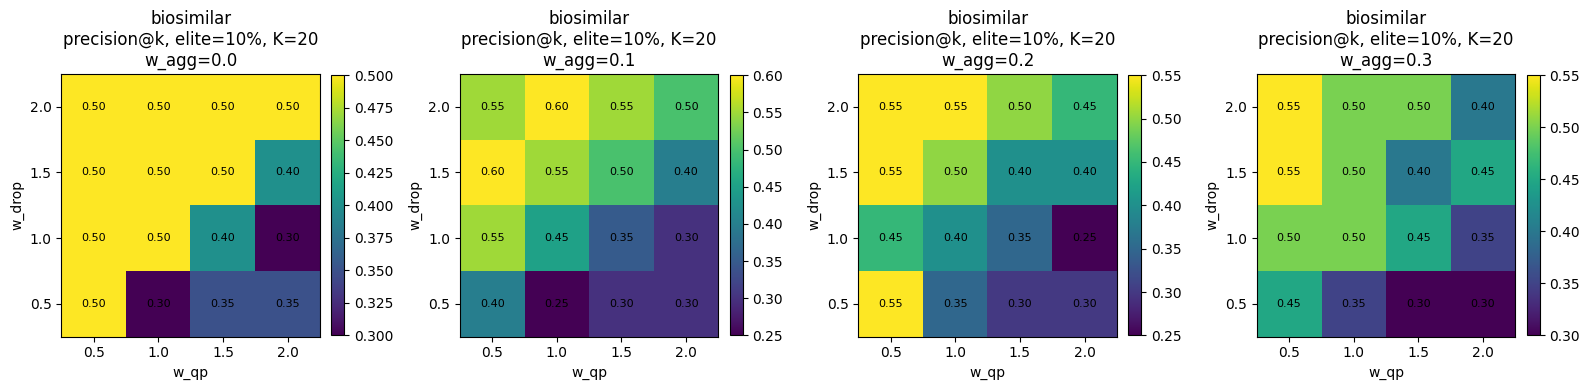

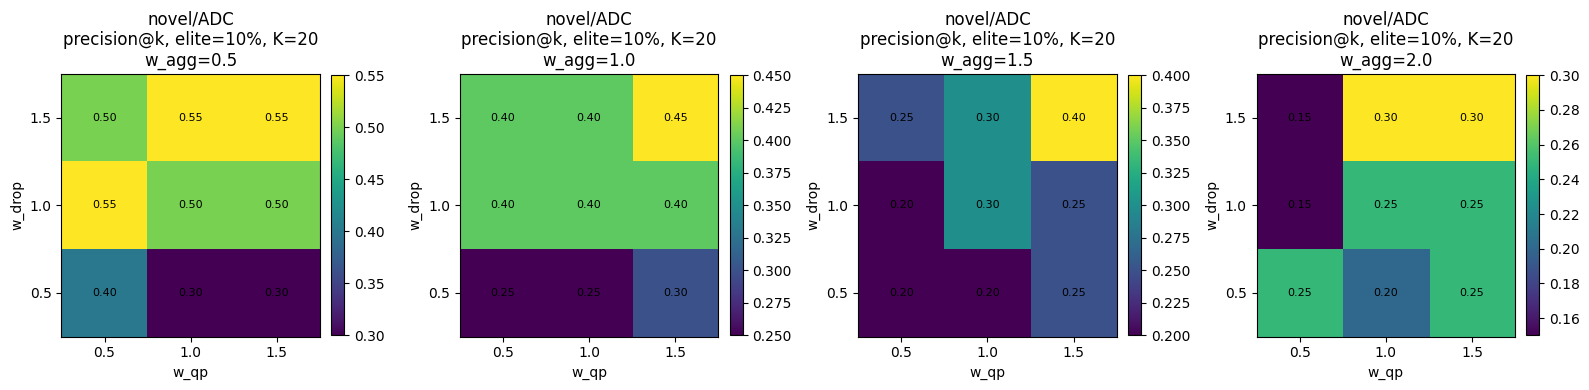

In [20]:

# Choose what to inspect
TARGET_K = 20
TARGET_ELITE = 0.10   # top 10%
METRIC = "precision@k"   # or "ndcg@k"

def plot_weight_heatmaps(sweep_df, mode_name, metric="precision@k", elite_frac=0.10, k=20):
    sub = sweep_df[
        (sweep_df["mode"] == mode_name) &
        (sweep_df["elite_frac"] == elite_frac) &
        (sweep_df["k"] == k)
    ].copy()

    w_agg_values = sorted(sub["w_agg"].unique())

    n_panels = len(w_agg_values)
    fig, axes = plt.subplots(1, n_panels, figsize=(4 * n_panels, 4), squeeze=False)
    axes = axes[0]

    for ax, wagg in zip(axes, w_agg_values):
        tmp = sub[sub["w_agg"] == wagg].copy()

        pivot = tmp.pivot_table(
            index="w_drop",
            columns="w_qp",
            values=metric
        ).sort_index(ascending=False)

        im = ax.imshow(pivot.values, aspect="auto")
        ax.set_title(f"{mode_name}\n{metric}, elite={int(elite_frac*100)}%, K={k}\nw_agg={wagg}")
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels(pivot.columns)
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels(pivot.index)
        ax.set_xlabel("w_qp")
        ax.set_ylabel("w_drop")

        # annotate cells
        for i in range(pivot.shape[0]):
            for j in range(pivot.shape[1]):
                val = pivot.values[i, j]
                ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)

        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

plot_weight_heatmaps(sweep, "biosimilar", metric=METRIC, elite_frac=TARGET_ELITE, k=TARGET_K)
plot_weight_heatmaps(sweep, "novel/ADC", metric=METRIC, elite_frac=TARGET_ELITE, k=TARGET_K)

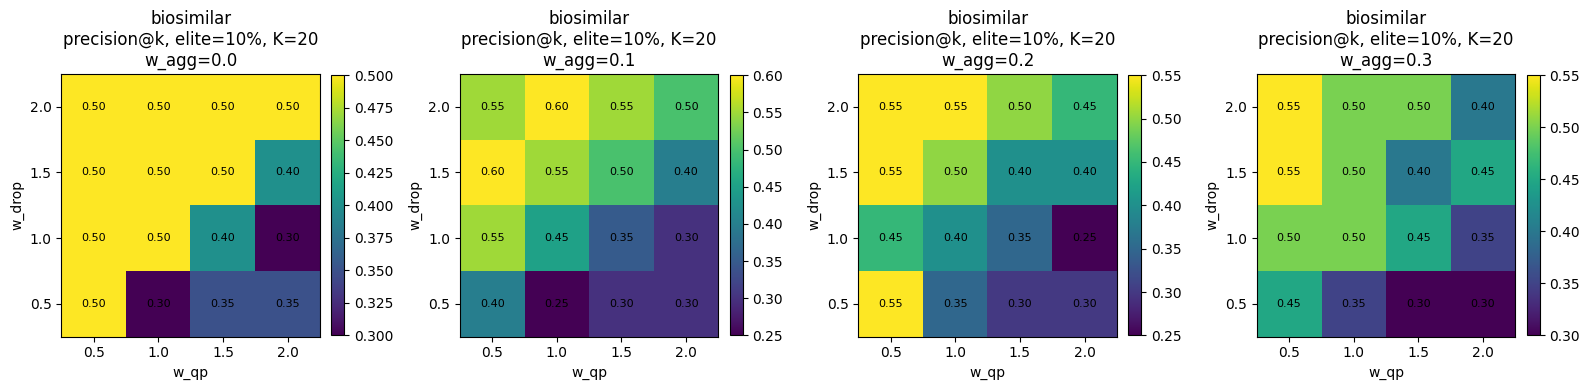

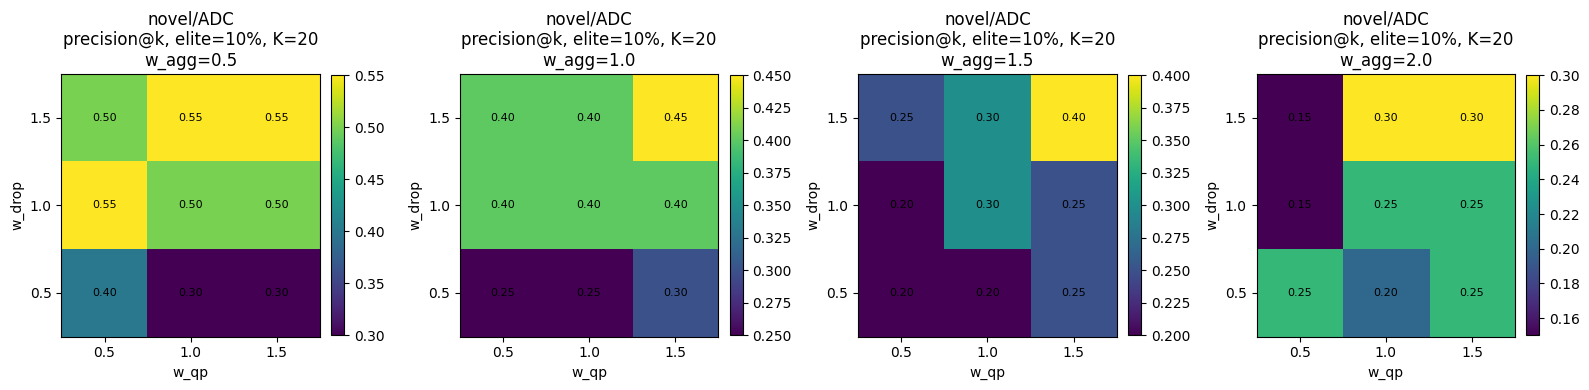

In [21]:
plot_weight_heatmaps(sweep, mode_name="biosimilar", metric="precision@k", elite_frac=0.10, k=20)
plot_weight_heatmaps(sweep, mode_name="novel/ADC", metric="precision@k", elite_frac=0.10, k=20)

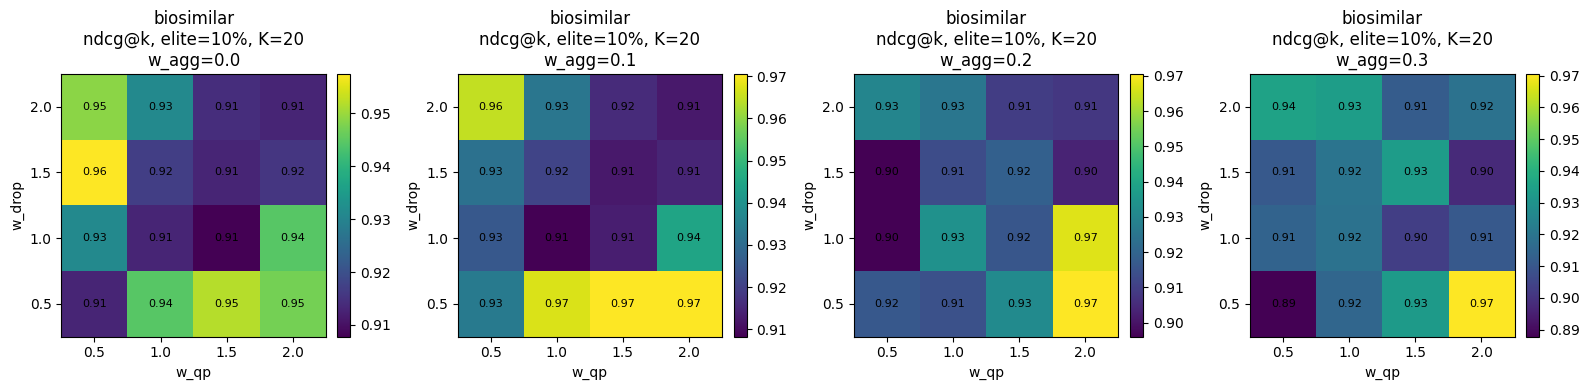

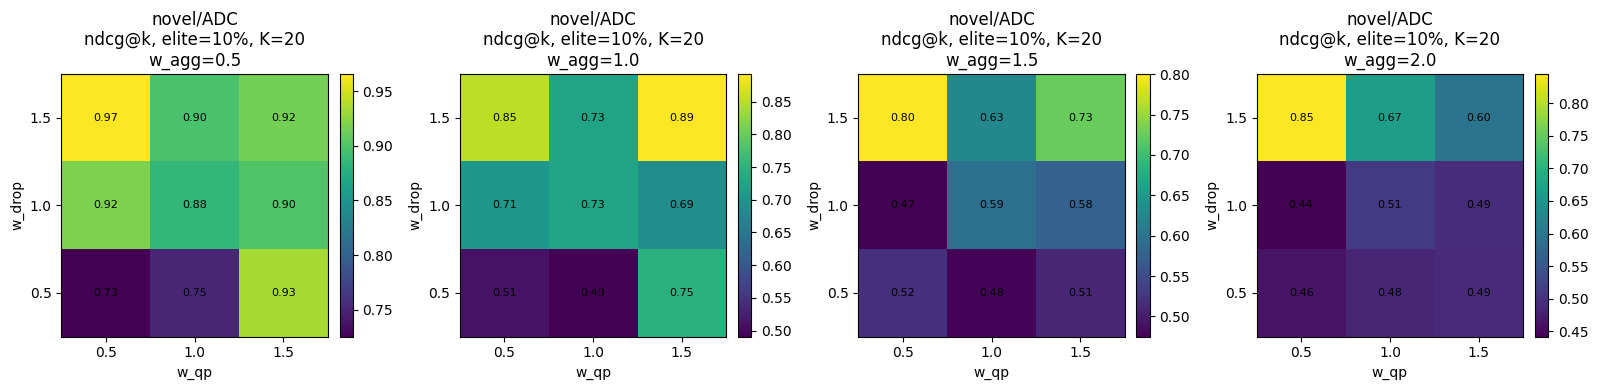

In [22]:
plot_weight_heatmaps(sweep, mode_name="biosimilar", metric="ndcg@k", elite_frac=0.10, k=20)
plot_weight_heatmaps(sweep, mode_name="novel/ADC", metric="ndcg@k", elite_frac=0.10, k=20)

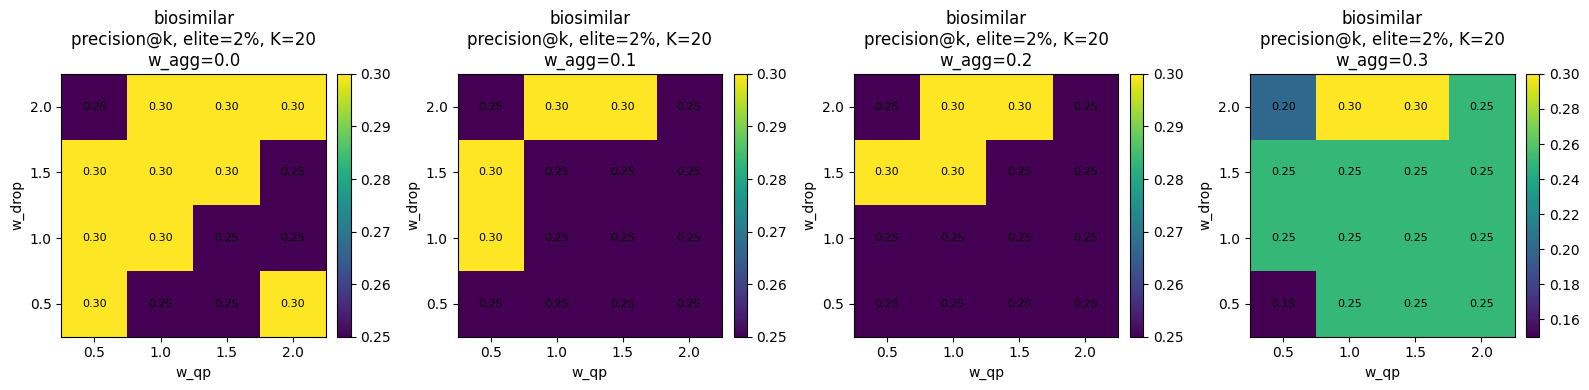

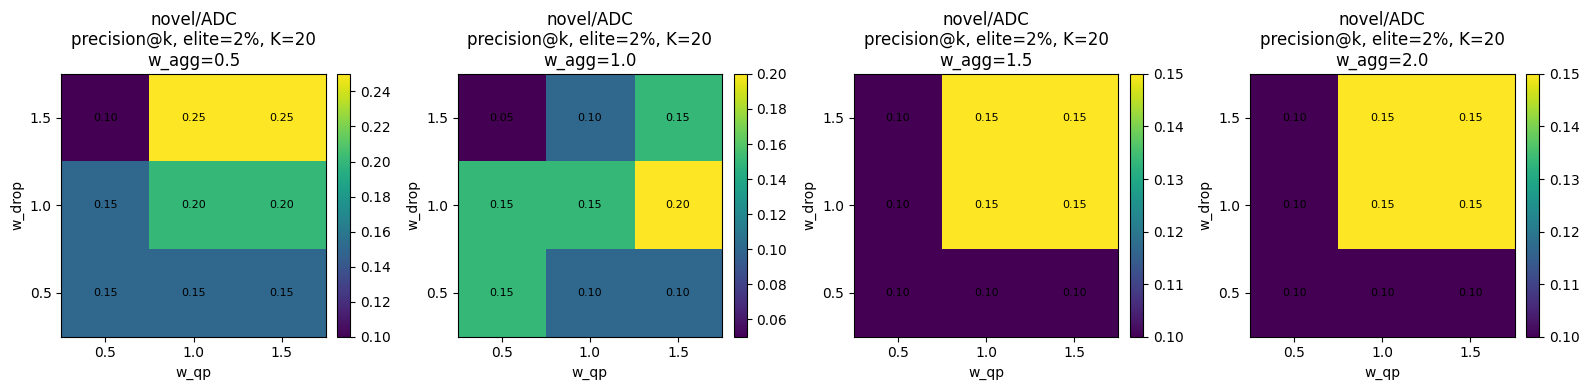

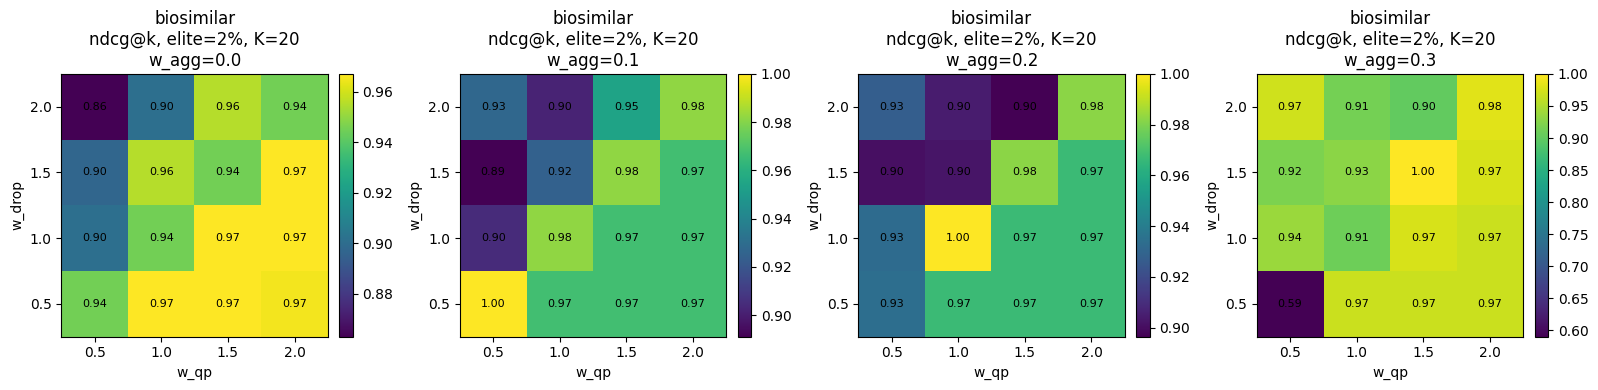

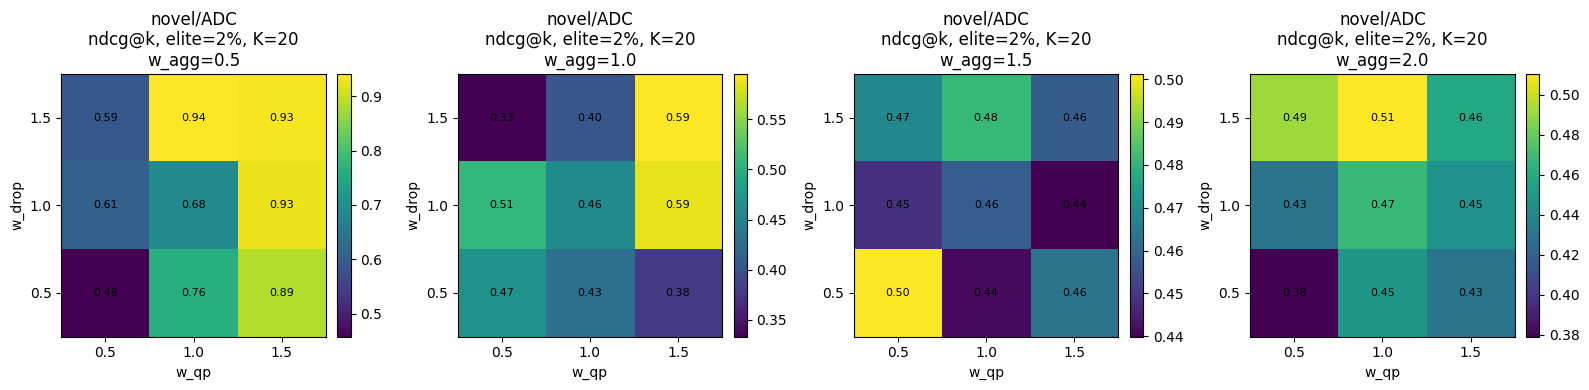

In [23]:
plot_weight_heatmaps(sweep, mode_name="biosimilar", metric="precision@k", elite_frac=0.02, k=20)
plot_weight_heatmaps(sweep, mode_name="novel/ADC", metric="precision@k", elite_frac=0.02, k=20)

plot_weight_heatmaps(sweep, mode_name="biosimilar", metric="ndcg@k", elite_frac=0.02, k=20)
plot_weight_heatmaps(sweep, mode_name="novel/ADC", metric="ndcg@k", elite_frac=0.02, k=20)

## Sanity Check 1 — Feature leakage check

We verify that the feature matrix `X` does **not** contain:

- late-stage target columns
- derived prediction columns
- utility columns
- elite labels
- subgroup target labels

This is the most important sanity check when performance looks unusually high.

Expected result:
- no exact forbidden columns in `X`
- no suspicious late-stage label leakage

In [24]:
print("X shape:", X.shape)
print("Columns in X that look suspicious:")
sus = [c for c in X.columns if (
    "late_" in c.lower()
    or "drop" in c.lower()
    or "stable" in c.lower()
    or "utility" in c.lower()
    or "elite" in c.lower()
    or c.lower().startswith("true_")
    or c.lower().startswith("pred_")
)]
print(sus)

X shape: (5000, 52)
Columns in X that look suspicious:
[]


In [25]:
# --------------------------------------------------
# Sanity Check 1 — Feature leakage check
# --------------------------------------------------

# Exact forbidden columns: targets, predictions, utilities, subgroup labels
forbidden_exact = {
    # current qP-based targets
    "late_mean_qp",
    "qp_drop_pct",
    "stable_label_30pct",
    "late_mean_aggregation",

    # old naming (keep here too, in case old files were mixed in)
    "productivity_drop_pct",
    "late_mean_titer",

    # prediction-table columns
    "true_qp_drop",
    "pred_qp_drop",
    "true_late_qp",
    "pred_late_qp",
    "true_late_agg",
    "pred_late_agg",
    "true_stable_label",
    "pred_stable_prob",
    "pred_stable_label",

    # old prediction-table naming
    "true_drop",
    "pred_drop",
    "true_late_titer",
    "pred_late_titer",

    # utility / ranking derived columns
    "true_util_bio",
    "pred_util_bio",
    "true_util_novel",
    "pred_util_novel",
    "true_util",
    "pred_util",

    # elite flags
    "elite",
    "elite_10",
    "elite_5",
    "elite_2",

    # subgroup labels
    "is_super",
    "is_aggressive",
}

# Pattern-based suspicious columns
forbidden_patterns = [
    "late_mean_",
    "true_",
    "pred_",
    "utility",
    "util_",
    "elite",
]

exact_hits = [c for c in X.columns if c in forbidden_exact]
pattern_hits = [c for c in X.columns if any(p in c.lower() for p in forbidden_patterns)]

print("=== Leakage Check ===")
print("Exact forbidden hits:", exact_hits)
print("Pattern-based suspicious hits:", pattern_hits)

if exact_hits:
    raise ValueError(f"Leakage detected in X (exact forbidden columns): {exact_hits}")

print("Leakage check done.")

=== Leakage Check ===
Exact forbidden hits: []
Pattern-based suspicious hits: []
Leakage check done.


## Sanity Check 2 — Permutation test

This test breaks the relationship between features and labels by shuffling the training targets.

If the model still performs well after permutation, that would suggest leakage or accidental shortcut learning.

If performance collapses, that supports that the model is learning real signal.

In [26]:
# --------------------------------------------------
# Sanity Check 2 — Permutation test
# --------------------------------------------------
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from scipy.stats import spearmanr
import numpy as np
import pandas as pd

def fit_rf_reg(X_train, y_train):
    model = RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        min_samples_leaf=5,
        max_features="sqrt"
    )
    model.fit(X_train, y_train)
    return model

rng = np.random.default_rng(42)
perm_results = []

targets_for_perm = [
    ("qp_drop", y_drop_train, y_drop_test),
    ("late_qp", y_prod_train, y_prod_test),
    ("late_agg", y_agg_train, y_agg_test),
]

for name, y_train_true, y_test_true in targets_for_perm:
    y_train_perm = rng.permutation(y_train_true)

    model_perm = fit_rf_reg(X_train, y_train_perm)
    pred_perm = model_perm.predict(X_test)

    r2_perm = r2_score(y_test_true, pred_perm)
    sp_perm = spearmanr(y_test_true, pred_perm).correlation

    perm_results.append({
        "target": name,
        "perm_r2": float(r2_perm),
        "perm_spearman": float(sp_perm),
    })

perm_df = pd.DataFrame(perm_results)
display(perm_df)

,target,perm_r2,perm_spearman
0,qp_drop,-0.011473,0.010591
1,late_qp,-0.000525,0.077462
2,late_agg,-0.052660,-0.168538


## Sanity Check 3 — Validation-only utility weight selection

This test checks whether utility weights are being implicitly tuned on the test set.

Procedure:

1. split the original training data into inner-train and validation
2. train models only on inner-train
3. choose utility weights on validation
4. evaluate those selected weights on untouched test data

If results remain reasonable, it means the utility formulation is not relying on test leakage.

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from scipy.stats import spearmanr
from sklearn.ensemble import RandomForestRegressor
import numpy as np
import pandas as pd

# --------------------------------------------------
# Helper functions
# --------------------------------------------------
def z(s):
    s = pd.Series(s).astype(float)
    return (s - s.mean()) / (s.std(ddof=0) + 1e-9)

def precision_at_k_df(df, score_col, elite_col, k):
    top = df.sort_values(score_col, ascending=False).head(k)
    return float(top[elite_col].mean())

def ndcg_at_k_df(df, score_col, elite_col, k):
    top = df.sort_values(score_col, ascending=False).head(k)
    rel = top[elite_col].values.astype(float)
    discounts = 1.0 / np.log2(np.arange(2, len(rel) + 2))
    dcg = float(np.sum(rel * discounts))
    ideal = np.sort(rel)[::-1]
    idcg = float(np.sum(ideal * discounts)) + 1e-12
    return dcg / idcg

def make_util_from_cols(df, prefix, w_qp, w_drop, w_agg):
    return (
        w_qp   * z(df[f"{prefix}_late_qp"])
        - w_drop * z(df[f"{prefix}_qp_drop"])
        - w_agg  * z(df[f"{prefix}_late_agg"])
    )

def fit_rf_reg_small(X_train, y_train):
    model = RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        min_samples_leaf=5,
        max_features="sqrt"
    )
    model.fit(X_train, y_train)
    return model

# --------------------------------------------------
# Split current train into inner-train and validation
# --------------------------------------------------
inner_train_idx, val_idx = train_test_split(
    train_idx,
    test_size=0.25,
    random_state=123,
    shuffle=True
)

X_inner = X.iloc[inner_train_idx].copy()
X_val   = X.iloc[val_idx].copy()
X_hold  = X.iloc[test_idx].copy()

# true labels
y_drop_inner = y_drop.iloc[inner_train_idx].values
y_drop_val   = y_drop.iloc[val_idx].values
y_drop_hold  = y_drop.iloc[test_idx].values

y_prod_inner = y_prod.iloc[inner_train_idx].values
y_prod_val   = y_prod.iloc[val_idx].values
y_prod_hold  = y_prod.iloc[test_idx].values

y_agg_inner  = y_agg.iloc[inner_train_idx].values
y_agg_val    = y_agg.iloc[val_idx].values
y_agg_hold   = y_agg.iloc[test_idx].values

# --------------------------------------------------
# Train on inner-train only
# --------------------------------------------------
rf_drop_val = fit_rf_reg_small(X_inner, y_drop_inner)
rf_prod_val = fit_rf_reg_small(X_inner, y_prod_inner)
rf_agg_val  = fit_rf_reg_small(X_inner, y_agg_inner)

# --------------------------------------------------
# Build validation dataframe
# --------------------------------------------------
val_df = pd.DataFrame({
    "true_qp_drop": y_drop_val,
    "pred_qp_drop": rf_drop_val.predict(X_val),
    "true_late_qp": y_prod_val,
    "pred_late_qp": rf_prod_val.predict(X_val),
    "true_late_agg": y_agg_val,
    "pred_late_agg": rf_agg_val.predict(X_val),
})

# --------------------------------------------------
# Build holdout test dataframe
# --------------------------------------------------
hold_df = pd.DataFrame({
    "true_qp_drop": y_drop_hold,
    "pred_qp_drop": rf_drop_val.predict(X_hold),
    "true_late_qp": y_prod_hold,
    "pred_late_qp": rf_prod_val.predict(X_hold),
    "true_late_agg": y_agg_hold,
    "pred_late_agg": rf_agg_val.predict(X_hold),
})

# --------------------------------------------------
# Small sweep (fast sanity version)
# --------------------------------------------------
grid_bio_small = {
    "w_qp":   [0.5, 1.0, 1.5],
    "w_drop": [0.5, 1.0, 1.5, 2.0],
    "w_agg":  [0.0, 0.1, 0.2],
}
grid_novel_small = {
    "w_qp":   [0.5, 1.0],
    "w_drop": [0.5, 1.0, 1.5],
    "w_agg":  [0.5, 1.0, 1.5],
}

TARGET_K = 20
ELITE_FRAC = 0.10

def sweep_best_on_validation(mode_name, grid, val_df):
    rows = []

    for w_qp in grid["w_qp"]:
        for w_drop in grid["w_drop"]:
            for w_agg in grid["w_agg"]:
                tmp = val_df.copy()

                tmp["true_util"] = make_util_from_cols(tmp, "true", w_qp, w_drop, w_agg)
                tmp["pred_util"] = make_util_from_cols(tmp, "pred", w_qp, w_drop, w_agg)

                thr = tmp["true_util"].quantile(1 - ELITE_FRAC)
                tmp["elite"] = (tmp["true_util"] >= thr).astype(int)

                rows.append({
                    "mode": mode_name,
                    "w_qp": w_qp,
                    "w_drop": w_drop,
                    "w_agg": w_agg,
                    "precision@20_val": precision_at_k_df(tmp, "pred_util", "elite", TARGET_K),
                    "ndcg@20_val": ndcg_at_k_df(tmp, "pred_util", "elite", TARGET_K),
                    "spearman_val": float(spearmanr(tmp["true_util"], tmp["pred_util"]).correlation),
                })

    out = pd.DataFrame(rows).sort_values(
        ["precision@20_val", "ndcg@20_val", "spearman_val"],
        ascending=False
    )
    return out

best_bio_val = sweep_best_on_validation("biosimilar", grid_bio_small, val_df).head(1)
best_novel_val = sweep_best_on_validation("novel/ADC", grid_novel_small, val_df).head(1)

display(best_bio_val)
display(best_novel_val)

# --------------------------------------------------
# Evaluate chosen weights on untouched holdout test
# --------------------------------------------------
def evaluate_chosen_weights(row, hold_df):
    w_qp   = row["w_qp"]
    w_drop = row["w_drop"]
    w_agg  = row["w_agg"]
    mode   = row["mode"]

    tmp = hold_df.copy()
    tmp["true_util"] = make_util_from_cols(tmp, "true", w_qp, w_drop, w_agg)
    tmp["pred_util"] = make_util_from_cols(tmp, "pred", w_qp, w_drop, w_agg)

    thr = tmp["true_util"].quantile(1 - ELITE_FRAC)
    tmp["elite"] = (tmp["true_util"] >= thr).astype(int)

    return {
        "mode": mode,
        "w_qp": w_qp,
        "w_drop": w_drop,
        "w_agg": w_agg,
        "precision@20_test": precision_at_k_df(tmp, "pred_util", "elite", TARGET_K),
        "ndcg@20_test": ndcg_at_k_df(tmp, "pred_util", "elite", TARGET_K),
        "spearman_test": float(spearmanr(tmp["true_util"], tmp["pred_util"]).correlation),
    }

val_selected_results = pd.DataFrame([
    evaluate_chosen_weights(best_bio_val.iloc[0], hold_df),
    evaluate_chosen_weights(best_novel_val.iloc[0], hold_df),
])

display(val_selected_results)

,mode,w_qp,w_drop,w_agg,precision@20_val,ndcg@20_val,spearman_val
2,biosimilar,0.5,0.5,0.2,1.0,1.0,0.671308


,mode,w_qp,w_drop,w_agg,precision@20_val,ndcg@20_val,spearman_val
12,novel/ADC,1.0,1.0,0.5,1.0,1.0,0.676802


,mode,w_qp,w_drop,w_agg,precision@20_test,ndcg@20_test,spearman_test
0,biosimilar,0.5,0.5,0.2,0.55,0.894594,0.591247
1,novel/ADC,1.0,1.0,0.5,0.50,0.870861,0.604901


## Optional debug — inspect latent aggressive subgroup realism

This section is not required for prediction or downstream decision-making.

It is only used to verify whether the generator created the intended aggressive subgroup:

- higher early attractiveness
- lower stability
- faster decay
- more misleading early phenotype

In [28]:
# --------------------------------------------------
# Optional debug: inspect latent aggressive subgroup realism
# --------------------------------------------------
LATENT_FULL_PATH = Path(f"../data/synthetic/raw/clone_latent_truths_5000_{scenario}.csv")
lat_full = pd.read_csv(LATENT_FULL_PATH)

print("Aggressive prevalence:", float(lat_full["is_aggressive"].mean()))

summary_main = lat_full.groupby("is_aggressive")[[
    "productivity",
    "stability",
    "k_decay_i"
]].mean()

display(summary_main)

optional_cols = [
    "aggressive_vcd_boost_i",
    "aggressive_viab_bonus_i",
    "aggressive_titer_mult_i",
    "aggressive_late_decay_i",
]

existing_optional = [c for c in optional_cols if c in lat_full.columns]

if existing_optional:
    print("\nAggressive subgroup extra parameters (mean):")
    display(lat_full.groupby("is_aggressive")[existing_optional].mean())

    print("\nAggressive subgroup extra parameters (std):")
    display(lat_full.groupby("is_aggressive")[existing_optional].std())
else:
    print("\nNo aggressive subgroup extra parameter columns found in latent truth file.")

Aggressive prevalence: 0.0376


,productivity,stability,k_decay_i
is_aggressive,,,
0,93.637113,0.619821,0.052506
1,160.399441,0.547986,0.058669



Aggressive subgroup extra parameters (mean):


,aggressive_vcd_boost_i,aggressive_viab_bonus_i,aggressive_titer_mult_i,aggressive_late_decay_i
is_aggressive,,,,
0,1.000000,0.000000,1.000000,0.060000
1,1.242847,2.981115,1.117341,0.060117



Aggressive subgroup extra parameters (std):


,aggressive_vcd_boost_i,aggressive_viab_bonus_i,aggressive_titer_mult_i,aggressive_late_decay_i
is_aggressive,,,,
0,0.000000,0.00000,0.000000,0.000000
1,0.103851,0.83469,0.049002,0.018318


## Output of Notebook 03b

This notebook produces a prediction table for downstream clone selection.

### Core predicted late-stage outcomes

- predicted late-stage **qP drop**
  - `pred_qp_drop`
- predicted late-stage **qP**
  - `pred_late_qp`
- predicted late-stage **aggregation**
  - `pred_late_agg`
- predicted probability of being **stable**
  - `pred_stable_prob`
  - `pred_stable_label`

### Optional subgroup probabilities

- `pred_super_prob`
  - probability of belonging to the rare high-value super clone subgroup
- `pred_aggr_prob`
  - probability of belonging to the aggressive / misleading early performer subgroup

### Rescue scoring outputs

- `pred_rescue_score`
  - model-derived score for identifying clones with process-optimization potential
- `pred_rescue_label`
  - top rescue-candidate flag based on the rescue score

### Pipeline meaning

- **Notebook 03b = prediction engine**
- **Notebook 04b = decision / selection engine**

The saved prediction table is passed to Notebook 04b, where predicted late-stage outcomes and rescue scores are used for:

- pass / rescue / fail bucket assignment
- stage-2 re-ranking
- final Top-K clone selection
- decision validation